# RLSSM Restless Learner Tutorial: One Learner, Two Decision Parameters

The [basic](rlssm_basic.ipynb) and [advanced](rlssm_advanced.ipynb) tutorials each
let a learner shape **one** part of the decision: the trial-wise drift rate `v`. The
other decision parameters — boundary separation `a`, starting point `z`, non-decision
time `t`, and the angle/collapse parameter `theta` — stayed fixed within a
participant.

Here we lift that restriction. A single Rescorla–Wagner learner drives **two**
decision parameters at once:

- its value **difference** sets the drift `v` (as before), and
- its total value **magnitude** sets the angle parameter `theta`, so the decision
  boundary collapses at a rate that itself changes with learning.

The one new ingredient is `computed_param_mapping`, which routes each of the learner's
outputs to a named SSM parameter. Everything downstream — the
`RLSSMConfig.from_ssms_model` bridge, the hierarchical fit, recovery, and
`mode="ppc"` checks — is identical to the earlier tutorials.

> **Where this sits in the suite:** start with
> [RLSSM basics](rlssm_basic.ipynb) if the bridge or hierarchical fit is new, and see
> [building a custom model](rlssm_advanced.ipynb) for a task environment with several
> conditions. The last tutorial,
> [HSSM-native custom model registration](rlssm_hssm_custom_models.ipynb), shows the
> shorter registry-based path.

## 1. One learning process, two computed parameters, two timescales

An RLSSM couples a slow process and a fast one. On each trial:

1. the **learner** holds a value state (here two Q-values) that changes slowly across
   trials as feedback arrives; and
2. the **decision model** turns the current decision parameters into a single choice
   and response time within that trial.

In the basic tutorial the learner computed only `v`. A learning process may instead
declare **several** computed outputs. Our learner declares two:

$$
v_t = (Q_{1,t}-Q_{0,t})\,\text{scaler}, \qquad
\theta_t = \text{urgency\_gain}\,(Q_{0,t}+Q_{1,t}).
$$

`computed_param_mapping = {"drift": "v", "urgency": "theta"}` connects the learner's
local output names (`drift`, `urgency`) to the SSM's parameter names (`v`, `theta`).
Because both `v` and `theta` are now computed every trial, they are **not** free
parameters to estimate — HSSM recovers only the learner's parameters
(`rl_alpha`, `scaler`, `urgency_gain`) and the remaining fixed SSM parameters
(`a`, `z`, `t`).

**Why couple `theta` to value at all?** The angle model's boundary starts at `a` and
narrows over the course of a single decision; larger `theta` makes it narrow faster,
so evidence is required to accumulate less before a response is committed. Tying
`theta` to total value $Q_0+Q_1$ makes this collapse **sharpen as the participant
learns** — an illustrative value-dependent urgency signal, not a canonical
psychological mechanism. The two timescales interact: across trials, learning raises
$\theta_t$; within a trial, a higher $\theta_t$ collapses the boundary sooner.

## 2. Setup

In [1]:
import logging
import os
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import hssm
import ssms.rl as rl
from ssms.rl.env import Bandit

warnings.filterwarnings("ignore")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

# HSSM and the JAX learner must agree on numerical precision.
hssm.set_floatX("float32", update_jax=True)
RANDOM_SEED = 20260706

Setting PyTensor floatX type to float32.


Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


### 2.1 Simulation and sampling scale

The same notebook serves a quick documentation build and a richer committed run. Set
the environment variable `FULL_RUN=1` for the latter. We deliberately start the
Q-values **low** (`INITIAL_Q = 0.20`): the urgency signal tracks the *sum* of the two
Q-values, and if learning started from `0.5` the winning arm's rise and the losing
arm's fall would roughly cancel, leaving the boundary-collapse trajectory flat and the
lesson invisible. Starting low lets the total value — and therefore `theta` — climb
visibly as the good option is discovered.

In [2]:
FULL_RUN = os.environ.get("FULL_RUN", "0") == "1"

N_PARTICIPANTS = 15 if FULL_RUN else 5
N_TRIALS = 150 if FULL_RUN else 70
N_CHAINS = 2
N_TUNE = 1000 if FULL_RUN else 300
N_DRAWS = 500 if FULL_RUN else 300
N_PPC_DRAWS = 20 if FULL_RUN else 8

INITIAL_Q = 0.20
REWARD_PROBS = [0.7, 0.3]   # option 0 (label -1) is the high-reward option
RESPONSE_LABELS = [-1, 1]   # angle SSM boundary labels

print(f"scale: {N_PARTICIPANTS} participants x {N_TRIALS} trials")

scale: 15 participants x 150 trials


## 3. Write the dual-output learning process

The learner is an ordinary two-armed Rescorla–Wagner rule with one twist: it returns
**two** computed quantities each trial instead of one. Three properties make the
multi-output contract explicit:

- `computed_params = ["drift", "urgency"]` — the learner produces two trial-wise
  outputs. These are *local* names; the model configuration will map them onto SSM
  parameters.
- `free_params = ["rl_alpha", "scaler", "urgency_gain"]` — the participant parameters
  supplied during simulation and estimated by HSSM. `scaler` converts the value
  *difference* into drift; `urgency_gain` converts the value *sum* into the angle
  parameter.
- `supports_gradient = True` with a `"jax"` backend — HSSM differentiates through the
  learner during NUTS sampling, so both a NumPy path (for ordinary simulation) and a
  JAX path (for gradients) are implemented.

`compute_*` runs **before** the decision and reads the current Q-values; `update_*`
runs **after** feedback arrives and adjusts the chosen option's value. The simulator
injects the zero-based `choice` into the context after the SSM responds, and the
`Bandit` environment supplies `feedback`.

In [3]:
class DualOutputRWLearner:
    "Rescorla-Wagner learner emitting drift (-> v) and urgency (-> theta)."

    def __init__(self, initial_q=0.5, feedback_field="feedback"):
        self._initial_q = initial_q
        self._feedback_field = feedback_field

    @property
    def computed_params(self):
        # Two trial-wise outputs; mapped to SSM names in the ModelConfig.
        return ["drift", "urgency"]

    @property
    def free_params(self):
        return ["rl_alpha", "scaler", "urgency_gain"]

    @property
    def param_bounds(self):
        return {
            "rl_alpha": (0.0, 1.0),
            "scaler": (0.001, 10.0),
            "urgency_gain": (0.0, 0.6),
        }

    @property
    def default_params(self):
        return {"rl_alpha": 0.2, "scaler": 2.0, "urgency_gain": 0.3}

    @property
    def available_backends(self):
        return ("python", "jax")

    @property
    def supports_gradient(self):
        return True

    @property
    def required_context_fields(self):
        # choice is injected by the simulator; feedback comes from the bandit.
        return ["choice", self._feedback_field]

    def init_state(self):
        return {"q_values": np.full(2, self._initial_q, dtype=np.float64)}

    def init_jax_state(self):
        import jax.numpy as jnp

        return {"q_values": jnp.full((2,), self._initial_q)}

    def compute_python(self, state, params, context):
        q = state["q_values"]
        # difference -> drift; sum -> urgency (both before the value update)
        return {
            "drift": float((q[1] - q[0]) * params["scaler"]),
            "urgency": float(params["urgency_gain"] * (q[0] + q[1])),
        }

    def compute_jax(self, state, params, context):
        q = state["q_values"]
        return {
            "drift": (q[1] - q[0]) * params["scaler"],
            "urgency": params["urgency_gain"] * (q[0] + q[1]),
        }

    def update_python(self, state, params, context):
        choice = int(context["choice"])
        feedback = float(context[self._feedback_field])
        q = np.asarray(state["q_values"], dtype=np.float64).copy()
        q[choice] += params["rl_alpha"] * (feedback - q[choice])
        return {"q_values": q}

    def update_jax(self, state, params, context):
        choice = context["choice"]
        feedback = context[self._feedback_field]
        q = state["q_values"]
        return {"q_values": q.at[choice].add(params["rl_alpha"] * (feedback - q[choice]))}

## 4. Assemble the model and route the two outputs

`ModelConfig` binds the learner to a registered decision process (`"angle"`) and a
task environment. The `Bandit.bernoulli` factory builds a two-armed Bernoulli bandit
whose response labels `[-1, 1]` match the angle SSM's two boundaries. The crucial
argument is `computed_param_mapping`: it declares that the learner's `drift` output
supplies the SSM's `v` and its `urgency` output supplies `theta`.

`validate()` checks the cross-component contract; `assemble(backend="jax")` resolves
the learner/SSM handshake. The two assertions below are the heart of this tutorial:
after assembly, exactly `{"v", "theta"}` are learner-computed, and a gradient is
available for NUTS.

In [4]:
ssms_config = rl.ModelConfig(
    model_name="DualOutput_RW_Angle",
    description="RW learner driving both drift (v) and the angle parameter (theta).",
    decision_process="angle",
    learning_process=DualOutputRWLearner(initial_q=INITIAL_Q),
    task_environment=Bandit.bernoulli(
        probabilities=REWARD_PROBS, response_labels=RESPONSE_LABELS
    ),
    computed_param_mapping={"drift": "v", "urgency": "theta"},
)

ssms_config.validate()
assembled = ssms_config.assemble(backend="jax")
print("free parameters:", ssms_config.list_params)
print("learner-computed SSM parameters:", assembled.computed_params)
print("gradient support:", assembled.gradient)
assert set(assembled.computed_params) == {"v", "theta"}
assert assembled.gradient == "available"

free parameters: ['rl_alpha', 'scaler', 'urgency_gain', 'a', 'z', 't']
learner-computed SSM parameters: ['v', 'theta']
gradient support: available


Because this is a recovery tutorial, we simulate from known group means with genuine
participant differences, then try to recover them. Only the **six free** parameters
appear here — `rl_alpha`, `scaler`, `urgency_gain`, `a`, `z`, `t`. The two computed
parameters `v` and `theta` are produced by the learner every trial and must **never**
be placed in the simulation `theta`; doing so would double-specify them and break the
bridge.

Each parameter gets its own between-participant spread. A bounded quantity such as `z`
varies far less than the drift `scaler`, so a single flat SD would be inappropriate.
The helper draws one value per participant, clips it to the supported range, and
returns both the array-valued `theta` for the simulator and a table of truths.

In [5]:
GROUP_THETA = {
    "rl_alpha": 0.08,       # learning rate (small -> a visibly gradual curve)
    "scaler": 2.50,         # value difference -> drift gain
    "urgency_gain": 0.30,   # value sum -> angle/collapse gain
    "a": 1.20,              # boundary separation
    "z": 0.50,              # starting-point bias (0.5 = unbiased)
    "t": 0.25,              # non-decision time (seconds)
}
# Modest, parameter-specific between-participant SDs. These are deliberately
# tighter than in the earlier tutorials: the urgency->theta coupling makes the
# hierarchical posterior funnel-prone (see the sampling note in Section 8), and
# keeping the population compact yields well-behaved geometry.
SDS = {
    "rl_alpha": 0.03,
    "scaler": 0.30,
    "urgency_gain": 0.05,
    "a": 0.12,
    "z": 0.04,
    "t": 0.03,
}
BOUNDS = {
    "rl_alpha": (0.01, 1.0),
    "scaler": (0.1, 5.0),
    "urgency_gain": (0.0, 0.6),
    "a": (0.3, 2.5),
    "z": (0.1, 0.9),
    "t": (0.05, 1.0),
}
LIST_PARAMS = list(GROUP_THETA)


def make_participant_theta(group_theta, sds, bounds, n_participants, rng):
    "Draw bounded participant parameters around known group means."
    theta = {
        name: np.clip(
            rng.normal(group_theta[name], sds[name], n_participants), *bounds[name]
        )
        for name in group_theta
    }
    true = pd.DataFrame(theta)
    true.index.name = "participant_id"
    return theta, true


rng = np.random.default_rng(RANDOM_SEED)
theta_arrays, true_params = make_participant_theta(
    GROUP_THETA, SDS, BOUNDS, N_PARTICIPANTS, rng
)
true_params.round(3)

,rl_alpha,scaler,urgency_gain,a,z,t
participant_id,,,,,,
0,0.084,2.350,0.328,1.191,0.514,0.272
1,0.070,2.781,0.317,1.104,0.478,0.220
2,0.070,2.697,0.187,1.139,0.488,0.263
3,0.081,2.605,0.300,1.127,0.495,0.237
4,0.019,2.495,0.272,1.152,0.438,0.252
5,0.102,2.769,0.315,0.983,0.438,0.283
6,0.088,2.765,0.327,1.208,0.501,0.189
7,0.080,2.290,0.263,1.097,0.456,0.208
8,0.083,2.615,0.322,0.940,0.505,0.245


One simulator call runs the full trial loop — compute `v` and `theta`, simulate the
choice and RT, deliver feedback, update the Q-values — for every participant.
`validate_data(...).raise_for_errors()` then checks the real dataframe (required
columns, balanced participant panels, valid responses, usable context) so any data
problem surfaces here rather than deep inside the likelihood.

In [6]:
data = rl.Simulator(ssms_config).simulate(
    theta=theta_arrays,
    n_trials=N_TRIALS,
    n_participants=N_PARTICIPANTS,
    random_state=RANDOM_SEED,
)
ssms_config.validate_data(data).raise_for_errors()

print("rows:", len(data), "| columns:", list(data.columns))
data.head()

rows: 2250 | columns: ['participant_id', 'trial_id', 'rt', 'response', 'feedback']


,participant_id,trial_id,rt,response,feedback
0,0,0,0.540830,1,1.0
1,0,1,0.642128,-1,0.0
2,0,2,1.438648,1,0.0
3,0,3,0.788364,-1,1.0
4,0,4,1.091819,1,0.0


## 5. The restless signature: latent `v` and `theta` paths

Before fitting, it helps to *see* the two coupled parameters the learner produced. We
replay each participant's own observed choices and feedback through the learning rule
to reconstruct the pre-decision `v` and `theta` that drove every trial, then average
these paths across participants in trial bins.

This is the "restless" signature of the model: as the good option is discovered, the
value difference grows (drift moves away from zero) **and** the total value grows
(the angle parameter `theta` climbs, so the boundary collapses faster). A single
learning process is moving two decision parameters on the slow, across-trial
timescale.

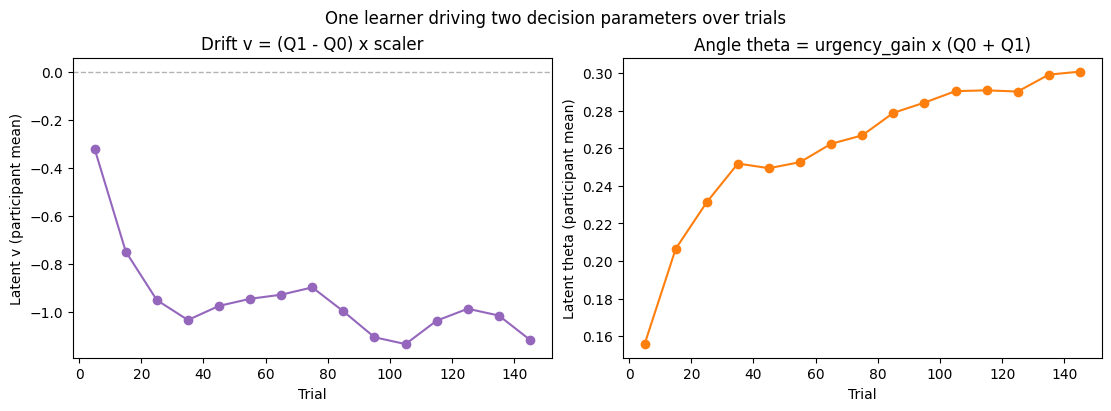

theta rises by +0.145
v moves by     -0.794


In [7]:
def reconstruct_latent_paths(dataframe, true_values, initial_q=INITIAL_Q):
    "Replay observed choices/feedback per participant to recover pre-decision v, theta."
    learner = DualOutputRWLearner(initial_q=initial_q)
    records = []
    for participant_id, trials in dataframe.groupby("participant_id", observed=True):
        trials = trials.sort_values("trial_id")
        params = {
            name: float(true_values.loc[participant_id, name])
            for name in ["rl_alpha", "scaler", "urgency_gain"]
        }
        state = learner.init_state()
        for trial_number, (_, row) in enumerate(trials.iterrows()):
            computed = learner.compute_python(state, params, {})
            records.append(
                {
                    "participant_id": participant_id,
                    "trial": trial_number,
                    "v": computed["drift"],
                    "theta": computed["urgency"],
                }
            )
            choice = 0 if int(row["response"]) == -1 else 1
            state = learner.update_python(
                state, params, {"choice": choice, "feedback": float(row["feedback"])}
            )
    return pd.DataFrame(records)


BIN_SIZE = 10
latent = reconstruct_latent_paths(data, true_params)
latent["trial_bin"] = (latent["trial"] // BIN_SIZE) * BIN_SIZE
trajectory = latent.groupby("trial_bin")[["v", "theta"]].mean()
centers = trajectory.index + BIN_SIZE / 2

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(centers, trajectory["v"], "o-", color="tab:purple")
axes[0].axhline(0.0, color="0.7", ls="--", lw=1)
axes[0].set_title("Drift v = (Q1 - Q0) x scaler")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Latent v (participant mean)")
axes[1].plot(centers, trajectory["theta"], "o-", color="tab:orange")
axes[1].set_title("Angle theta = urgency_gain x (Q0 + Q1)")
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("Latent theta (participant mean)")
fig.suptitle("One learner driving two decision parameters over trials")
plt.show()

print(f"theta rises by {trajectory['theta'].iloc[-1] - trajectory['theta'].iloc[0]:+.3f}")
print(f"v moves by     {trajectory['v'].iloc[-1] - trajectory['v'].iloc[0]:+.3f}")

## 6. Bridge the model into HSSM

The bridge call is identical to the preset and custom-model tutorials. It inspects the
assembled `ssms.rl` model and builds HSSM metadata for the free parameters, their
bounds, the JAX learning function, and the trial-level context.

The assertion is what makes this notebook different from the earlier ones: **both** `v`
and `theta` are reported as learner-computed, so neither may appear among the sampled
parameters.

In [8]:
model_config = hssm.rl.RLSSMConfig.from_ssms_model(ssms_config)

print("list_params (free):", model_config.list_params)
print("computed by learner:", set(model_config.ssm_logp_func.computed))
assert set(model_config.ssm_logp_func.computed) == {"v", "theta"}
assert "v" not in model_config.list_params
assert "theta" not in model_config.list_params

list_params (free): ['rl_alpha', 'scaler', 'urgency_gain', 'a', 'z', 't']
computed by learner: {'theta', 'v'}


## 7. Specify hierarchical priors and build the model

As in the earlier tutorials, every free parameter gets a group intercept and a
participant deviation:

```
rl_alpha ~ 1 + (1 | participant_id)
```

The `TruncatedNormal` intercept prior respects each parameter's valid bounds. The
participant effect has fixed mean **0**, so the intercept alone owns the population
location while a `HalfNormal` prior learns how much participants vary.

In [9]:
PARTICIPANT_EFFECT_PRIOR = {
    "name": "Normal",
    "mu": 0,
    "sigma": {"name": "HalfNormal", "sigma": 0.5},
}


def hierarchical_param(name, lower, upper, mu, sigma):
    "Group intercept plus mean-zero participant deviations."
    return hssm.Param(
        name,
        formula=f"{name} ~ 1 + (1|participant_id)",
        prior={
            "Intercept": hssm.Prior(
                "TruncatedNormal", lower=lower, upper=upper, mu=mu, sigma=sigma
            ),
            "1|participant_id": PARTICIPANT_EFFECT_PRIOR,
        },
    )

The constructor receives the trial data and bridged config. `p_outlier=0` and
`lapse=None` disable mixture components to keep the tutorial focused. Only the six free
parameters are included — `v` and `theta` are absent because the learner computes them.

> **Important RLSSM sampling setting:** use `process_initvals=False`. Processed initial
> values can place this model in a region where the float32 NUTS step size collapses
> and the posterior stays near the prior despite the run finishing. Starting from the
> prior avoids that failure mode.

In [10]:
model = hssm.RLSSM(
    data=data,
    model_config=model_config,
    p_outlier=0,
    lapse=None,
    process_initvals=False,
    include=[
        hierarchical_param("rl_alpha", 0.01, 1.0, 0.15, 0.15),
        hierarchical_param("scaler", 0.1, 5.0, 2.5, 0.8),
        hierarchical_param("urgency_gain", 0.0, 0.6, 0.30, 0.15),
        hierarchical_param("a", 0.3, 2.5, 1.2, 0.3),
        hierarchical_param("z", 0.1, 0.9, 0.5, 0.15),
        hierarchical_param("t", 0.05, 1.0, 0.25, 0.1),
    ],
)

print("participants:", model.n_participants, "| trials/participant:", model.n_trials)
print("free parameters:", list(model.params))
assert "v" not in model.params
assert "theta" not in model.params

You supplied a model 'DualOutput_RW_Angle', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.


Model initialized successfully.


participants: 15 | trials/participant: 150
free parameters: ['rl_alpha', 'scaler', 'urgency_gain', 'a', 'z', 't']


Printing the model is a quick structural check. Every free parameter should have an
intercept and a participant term, while both `v` and `theta` are absent — the learner
supplies them trial by trial.

In [11]:
print(model.model)

       Formula: c(rt, response) ~ 1 + (1|participant_id)
                scaler ~ 1 + (1|participant_id)
                urgency_gain ~ 1 + (1|participant_id)
                a ~ 1 + (1|participant_id)
                z ~ 1 + (1|participant_id)
                t ~ 1 + (1|participant_id)
        Family: SSM Family
          Link: rl_alpha = identity
                scaler = identity
                urgency_gain = identity
                a = identity
                z = identity
                t = identity
  Observations: 2250
        Priors: 
    target = rl_alpha
        Common-level effects
            Intercept ~ TruncatedNormal(lower: 0.009999999776482582, upper: 1.0, mu: 0.15000000596046448,
                sigma: 0.15000000596046448)
        
        
        Group-level effects
            1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.5))
    target = scaler
        Common-level effects
            scaler_Intercept ~ TruncatedNormal(lower: 0.10000000149011612, u

## 8. Sample the posterior

NumPyro's NUTS sampler differentiates through the JAX learner. The doc-scale run is
intentionally short; `FULL_RUN=1` uses 1,000 warmup and 500 retained draws for the
committed recovery output.

Because one learner feeds **two** decision parameters, the hierarchical posterior is
more sharply curved (a "funnel") than in the single-output tutorials. We use
`target_accept=0.95` so NUTS takes smaller, more careful steps through that geometry.
This is a property of the *coupled model*, not of HSSM — the same bridge, priors, and
sampler handle it; the model simply asks more of the sampler.

In [12]:
idata = model.sample(
    sampler="numpyro",
    draws=N_DRAWS,
    tune=N_TUNE,
    chains=N_CHAINS,
    cores=N_CHAINS,
    target_accept=0.95,   # tighter steps for the coupled model's funnel geometry
    random_seed=RANDOM_SEED,
)
idata

Using default initvals. 



  0%|          | 0/1500 [00:00<?, ?it/s]

warmup:   0%|          | 1/1500 [00:01<31:08,  1.25s/it, 1 steps of size 1.78e+00. acc. prob=0.00]

warmup:   0%|          | 6/1500 [00:01<04:18,  5.79it/s, 37 steps of size 2.14e-03. acc. prob=0.49]

warmup:   1%|          | 9/1500 [00:03<10:50,  2.29it/s, 1023 steps of size 9.00e-05. acc. prob=0.54]

...

 51%|█████     | 511/1000 [00:00<00:00, 1428.81it/s]

 68%|██████▊   | 677/1000 [00:00<00:00, 1509.13it/s]

 84%|████████▍ | 844/1000 [00:00<00:00, 1562.45it/s]

100%|██████████| 1000/1000 [00:00<00:00, 1398.21it/s]

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

## 9. Parameter recovery

We recover the **six free** parameters only. `v` and `theta` are not estimated — they
are deterministic functions of the learner's state — so they never appear in the
recovery plots. As before we use two views:

1. group intercepts versus the known group means; and
2. each participant's intercept-plus-deviation estimate versus their true value.

All six parameters use identity links, so no inverse transformation is needed.

> **What this section is and isn't testing.** The purpose of this tutorial is to show
> that HSSM can *specify and fit* a flexible RLSSM in which one learner drives multiple
> decision parameters — that machinery works exactly as in the earlier tutorials.
> **How well each parameter can be recovered is a separate question**, and it is a
> property of the *model and design*, not of HSSM. Group-level recovery here is strong.
> Per-participant recovery is sharpest for the parameters with the most separable
> behavioral signature — the boundary `a` and the learning rate `rl_alpha` — and more
> modest for the rest. The drift and urgency scalers (`scaler`, `urgency_gain`) are
> harder because they act only through the *same* learned Q-values, and `z`/`t` are
> harder here because we deliberately gave them a narrow between-participant spread to
> keep the coupled geometry well-behaved (Section 8). Pinning any of these down more
> sharply is a design question — more trials per participant, wider true individual
> differences, or effects that separate the parameters — independent of the inference
> tool.

In [13]:
def group_recovery(idata, true_group):
    "Plot group intercept posteriors against known population means."
    names = [f"{name}_Intercept" for name in LIST_PARAMS]
    summary = az.summary(idata, var_names=names, kind="stats")
    summary.index = LIST_PARAMS
    summary["true"] = [true_group[name] for name in LIST_PARAMS]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    y = np.arange(len(LIST_PARAMS))
    ax.errorbar(
        summary["mean"],
        y,
        xerr=[
            summary["mean"] - summary["hdi_3%"],
            summary["hdi_97%"] - summary["mean"],
        ],
        fmt="o",
        capsize=4,
        label="posterior (94% HDI)",
    )
    ax.scatter(
        summary["true"], y, color="crimson", marker="D", zorder=5,
        label="true group mean"
    )
    ax.set_yticks(y)
    ax.set_yticklabels(LIST_PARAMS)
    ax.invert_yaxis()
    ax.set_title("Group-level recovery")
    ax.legend()
    fig.tight_layout()
    plt.show()
    return summary


def participant_recovery(idata, true_values):
    "Plot true versus recovered participant values for all six free parameters."
    post = idata.posterior
    fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
    correlations = {}

    for ax, name in zip(axes.ravel(), LIST_PARAMS):
        effect = post[f"{name}_1|participant_id"]
        participant_dim = [
            dim for dim in effect.dims if dim not in ("chain", "draw")
        ][0]
        draws = post[f"{name}_Intercept"] + effect
        recovered = draws.mean(("chain", "draw")).values
        lower = draws.quantile(0.03, ("chain", "draw")).values
        upper = draws.quantile(0.97, ("chain", "draw")).values
        participant_ids = [int(value) for value in effect[participant_dim].values]
        truth = true_values.loc[participant_ids, name].values
        correlation = float(np.corrcoef(truth, recovered)[0, 1])
        correlations[name] = correlation

        ax.errorbar(
            truth,
            recovered,
            yerr=[recovered - lower, upper - recovered],
            fmt="o",
            ecolor="0.7",
            capsize=3,
        )
        limits = [
            min(truth.min(), recovered.min()) - 0.03,
            max(truth.max(), recovered.max()) + 0.03,
        ]
        ax.plot(limits, limits, "k--", lw=1)
        ax.set_title(f"{name} (r = {correlation:.2f})")
        ax.set_xlabel("true")
        ax.set_ylabel("recovered")
        ax.grid(alpha=0.3)

    fig.suptitle("Participant-level recovery (dashed line = perfect)")
    plt.show()
    return pd.Series(correlations, name="correlation")

### 9.1 Group-level recovery

Each blue interval is the posterior 94% HDI for a group intercept; the red diamond is
the value used to simulate the data. A convincing recovery places the diamonds inside
or very near their intervals — including `urgency_gain`, the parameter unique to this
tutorial.

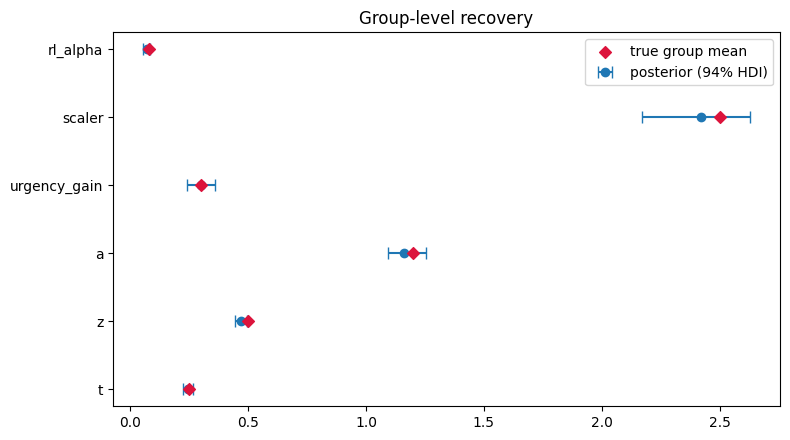

,mean,hdi_3%,hdi_97%,true
rl_alpha,0.070,0.055,0.085,0.08
scaler,2.422,2.170,2.628,2.50
urgency_gain,0.298,0.241,0.360,0.30
a,1.162,1.091,1.253,1.20
z,0.471,0.444,0.496,0.50
t,0.245,0.224,0.265,0.25


In [14]:
group_summary = group_recovery(idata, GROUP_THETA)
group_summary[["mean", "hdi_3%", "hdi_97%", "true"]].round(3)

### 9.2 Participant-level recovery

Each point reconstructs a participant's parameter as `Intercept + deviation` and
compares it with that participant's simulation truth. The boundary `a` and learning
rate `rl_alpha` line up tightest along the diagonal; `scaler`, `urgency_gain`, `z`, and
`t` recover more loosely, with wider error bars and more scatter. `scaler` and
`urgency_gain` influence behavior only by rescaling the *same* learned Q-values, so
they trade off against each other and against `a`; `z` and `t` simply have little
between-participant spread here by construction. The group-level estimates for all six
remain sound — it is the *per-participant* resolution that the model and design limit,
not HSSM's ability to fit the model.

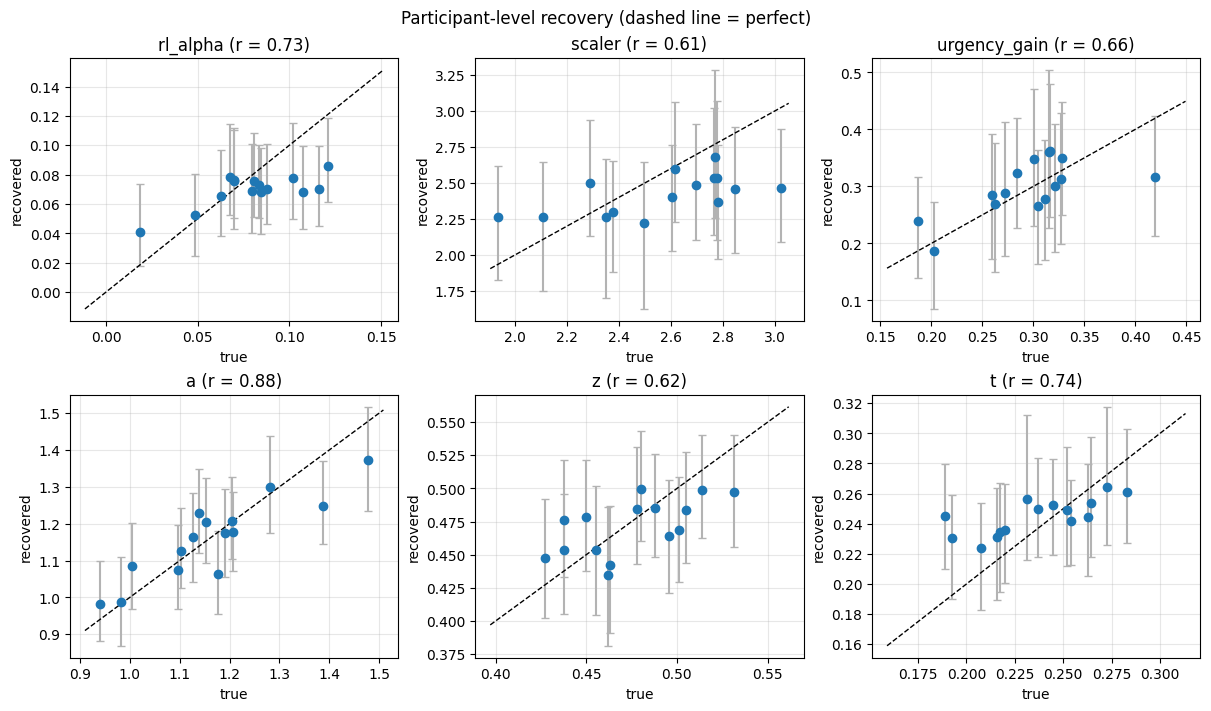

participant correlations:
rl_alpha        0.73
scaler          0.61
urgency_gain    0.66
a               0.88
z               0.62
t               0.74
max r-hat: 1.013 | divergences: 25


In [15]:
participant_correlations = participant_recovery(idata, true_params)

max_rhat = max(float(az.rhat(idata)[name].max()) for name in az.rhat(idata).data_vars)
divergences = int(idata.sample_stats["diverging"].sum())
print("participant correlations:")
print(participant_correlations.round(2).to_string())
print(f"max r-hat: {max_rhat:.3f} | divergences: {divergences}")

## 10. Posterior predictive checks

A posterior predictive check (PPC) asks whether the fitted parameters can regenerate
the behavioral patterns in the observed data. RLSSMs need care because every choice
and reward changes the learner's future state.

`ssms.rl` provides `mode="ppc"` for exactly this. It **replays each participant's
observed responses and feedback** when updating Q-values, so the predicted `v` and
`theta` trajectories follow the history that was actually observed. The choice and RT
on each trial are then **newly simulated** from a posterior parameter draw. This tests
the decision model along a comparable learning path rather than inventing a second,
unrelated reward history.

We draw several complete posterior samples. Each sample holds a coherent set of all
six parameters for every participant; mixing values across draws would destroy
posterior correlations. The helper rebuilds natural-scale participant values as
`Intercept + deviation`.

In [16]:
def draw_posterior_theta(idata, sample_idx):
    "Return one coherent posterior draw of every free participant parameter."
    posterior = idata.posterior.stack(sample=("chain", "draw"))
    theta = {}
    for name in LIST_PARAMS:
        effect = posterior[f"{name}_1|participant_id"]
        participant_dim = [dim for dim in effect.dims if dim != "sample"][0]
        values = (posterior[f"{name}_Intercept"] + effect).isel(sample=sample_idx)
        participant_ids = [int(value) for value in effect[participant_dim].values]
        ordered = pd.Series(
            np.asarray(values.values), index=participant_ids
        ).sort_index()
        theta[name] = ordered.reindex(range(N_PARTICIPANTS)).to_numpy()
    return theta


n_posterior_samples = idata.posterior.sizes["chain"] * idata.posterior.sizes["draw"]
ppc_rng = np.random.default_rng(RANDOM_SEED + 1)
sample_ids = ppc_rng.choice(
    n_posterior_samples,
    size=min(N_PPC_DRAWS, n_posterior_samples),
    replace=False,
)

ppc_frames = []
for ppc_draw, sample_idx in enumerate(sample_ids):
    theta_draw = draw_posterior_theta(idata, int(sample_idx))
    simulated = rl.Simulator(ssms_config).simulate(
        theta=theta_draw,
        mode="ppc",
        observed_data=data,
        random_state=RANDOM_SEED + 100 + ppc_draw,
    )
    simulated["ppc_draw"] = ppc_draw
    ppc_frames.append(simulated)

ppc_data = pd.concat(ppc_frames, ignore_index=True)
print(
    f"PPC datasets: {len(sample_ids)} | rows per dataset: {len(data)} | "
    f"total rows: {len(ppc_data)}"
)

PPC datasets: 20 | rows per dataset: 2250 | total rows: 45000


### 10.1 Observed vs. predicted learning curve

Option `0` maps to response `-1` and is the high-reward option. The observed black
line and the posterior-predictive blue line (with a 94% band across replicated
datasets) should climb together from chance toward a preference for the high-reward
option. A model that reproduces the learning curve has captured the drift side of the
coupling.

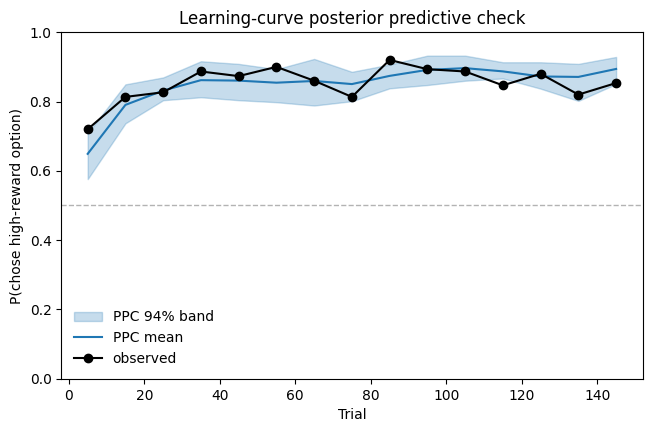

In [17]:
def binned_choice_curve(dataframe, include_draw=False, bin_size=10):
    "Summarize high-reward choices by within-participant trial bin."
    valid = dataframe[
        np.isfinite(dataframe["rt"])
        & (dataframe["rt"] > 0)
        & (dataframe["response"] > -900)
    ].copy()
    valid["chose_high"] = (valid["response"] == -1).astype(float)
    valid["trial_bin"] = (valid["trial_id"] // bin_size) * bin_size
    group_columns = ["trial_bin"]
    if include_draw:
        group_columns = ["ppc_draw", "trial_bin"]
    return (
        valid.groupby(group_columns, observed=True)["chose_high"]
        .mean()
        .reset_index()
    )


observed_curve = binned_choice_curve(data).set_index("trial_bin")["chose_high"]
predicted_curve = (
    binned_choice_curve(ppc_data, include_draw=True)
    .pivot(index="trial_bin", columns="ppc_draw", values="chose_high")
    .sort_index()
)
curve_centers = predicted_curve.index + BIN_SIZE / 2

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.fill_between(
    curve_centers,
    predicted_curve.quantile(0.03, axis=1),
    predicted_curve.quantile(0.97, axis=1),
    color="tab:blue",
    alpha=0.25,
    label="PPC 94% band",
)
ax.plot(curve_centers, predicted_curve.mean(axis=1), color="tab:blue", lw=1.5,
        label="PPC mean")
ax.plot(observed_curve.index + BIN_SIZE / 2, observed_curve.values, "o-",
        color="black", label="observed")
ax.axhline(0.5, color="0.7", ls="--", lw=1)
ax.set_ylim(0, 1)
ax.set_xlabel("Trial")
ax.set_ylabel("P(chose high-reward option)")
ax.set_title("Learning-curve posterior predictive check")
ax.legend(frameon=False)
plt.show()

### 10.2 Signed response times

Signed RT places both outcomes on one axis: negative values are the high-reward
response (`-1`), positive values the lower-reward response (`1`). This single view
checks the response proportions and the RT distribution together. Because `theta`
grows with learning, the model's boundary collapses faster on later trials — a
behavioral fingerprint the PPC should reproduce alongside the observed outline.

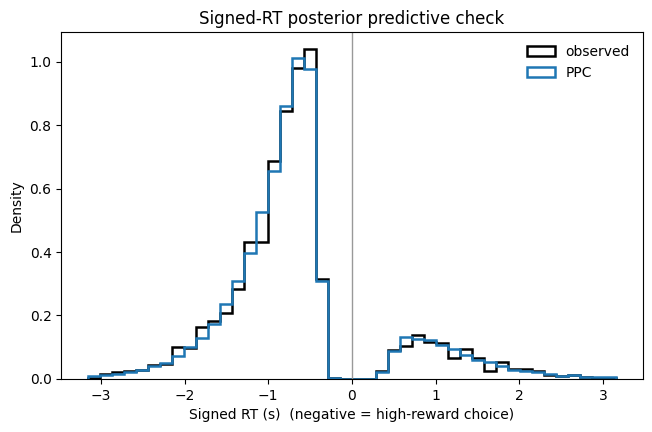

In [18]:
def signed_rt(dataframe):
    "Return finite RTs signed by response (- = high reward, + = low reward)."
    valid = dataframe[
        np.isfinite(dataframe["rt"])
        & (dataframe["rt"] > 0)
        & (dataframe["response"] > -900)
    ]
    return np.where(
        valid["response"].astype(int) == -1,
        -valid["rt"].astype(float),
        valid["rt"].astype(float),
    )


all_signed_rt = np.concatenate([signed_rt(data), signed_rt(ppc_data)])
rt_limit = np.quantile(np.abs(all_signed_rt), 0.995)
bins = np.linspace(-rt_limit, rt_limit, 45)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(signed_rt(data), bins=bins, density=True, histtype="step", lw=1.8,
        color="black", label="observed")
ax.hist(signed_rt(ppc_data), bins=bins, density=True, histtype="step", lw=1.8,
        color="tab:blue", label="PPC")
ax.axvline(0, color="0.6", lw=1)
ax.set_xlabel("Signed RT (s)  (negative = high-reward choice)")
ax.set_ylabel("Density")
ax.set_title("Signed-RT posterior predictive check")
ax.legend(frameon=False)
plt.show()

## 11. Summary

You have fitted an RLSSM in which **one learning process drives two decision
parameters**:

1. **Multiple computed outputs:** `DualOutputRWLearner` declares
   `computed_params = ["drift", "urgency"]` and computes both every trial from the same
   Q-values.
2. **Explicit routing:** `computed_param_mapping = {"drift": "v", "urgency": "theta"}`
   sends each output to a named SSM parameter, so `v` **and** `theta` are learner-
   computed and neither is sampled.
3. **A visible restless signature:** replaying the learning history shows the drift
   moving away from zero and the angle parameter `theta` climbing over trials — two
   parameters moving together on the slow timescale.
4. **The same downstream workflow:** the `RLSSMConfig.from_ssms_model` bridge,
   mean-zero hierarchical priors, and the `process_initvals=False` sampling recipe
   carry over unchanged — the coupled model only asks for a slightly more careful
   sampler (`target_accept=0.95`) to handle its funnel geometry.
5. **A coupled PPC:** `mode="ppc"` replays observed responses and feedback while newly
   simulating choices and RTs, testing both sides of the coupling at once.

**A note on recoverability.** This tutorial demonstrates that HSSM can *specify and
fit* this flexible RLSSM. How identifiable each parameter is — especially per
participant — is a separate property of the model and experimental design, not of
HSSM. Here group recovery is strong throughout, while the drift/urgency scalers
(`scaler`, `urgency_gain`) and the narrowly-distributed `z`/`t` are resolved less
sharply per participant. Improving that is a design question (more trials, wider true
individual differences, or effects that separate the parameters), independent of the
inference tool.

Continue with [HSSM-native custom model registration](rlssm_hssm_custom_models.ipynb)
for the shortest customization path, or revisit
[building a custom `ssms.rl` model](rlssm_advanced.ipynb) and
[RLSSM basics](rlssm_basic.ipynb).